In [2]:
import numpy as np 
import pickle 
import pandas as pd 
import re
%matplotlib inline 
import matplotlib.pyplot as plt 
import seaborn as sns
import yaml 
from pathlib import Path
import matplotlib
import re 
# matplotlib.rcParams.update({'font.size': 26})
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
import sys
sys.path.append('../')
sys.path.append('/mnt/home/jfeather/ceph/projects/auditory_brain_dnn_for_audio_ssl')

import figure_utils
from importlib import reloadf
reload(figure_utils)
from figure_utils import (
    format_model_str as format_model_str_utils,
    normalize_model_list,
    normalize_model_name,
    normalize_palette_dict,
    build_model_palette,
    get_standard_hue_order,
    get_standard_base_colors,
    model_label,
    plot_grouped_bars,
)

# import aud_dnn.analyze.plot_utils_AUD as plot_utils_AUD

ImportError: cannot import name 'reloadf' from 'importlib' (/mnt/home/igriffith/envs/cochdnn_ssl_pl/lib/python3.12/importlib/__init__.py)

In [29]:
updated_path = Path("/mnt/home/jfeather/ceph/projects/auditory_brain_dnn_for_audio_ssl/results/kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_0e-01_audioset_only/AUD-MAPPING-Ridge_TARGET-B2021_SOURCE-kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_0e-01_audioset_only-relu3_RANDNETW-False_ALPHALIMIT-50")
new_df = pd.read_pickle(updated_path / "df_output.pkl")


In [32]:
res_path = "/mnt/home/jfeather/ceph/projects/auditory_brain_dnn_for_audio_ssl/results/PLOTS_across-models/across-models_barplot_components_NH2015comp_CV-splits-nit-10_median_r2_test_sem_over_it_median_r2_test_performance_sorted.csv"
results_df = pd.read_csv(res_path)

In [33]:
results_df.source_model.unique()

array(['resnet18_barlow_invariant_only_lmbda_1e-2_lr_2e-1_w_invar_augment_no_avgpool_latest_ckpt',
       'resnet18_barlow_equivariant_lmbda_1e-2_lr_2e-1_w_invar_augment_no_avgpool_eq_lmbda_1e-02_latest_ckpt',
       'resnet18_barlow_equivariant_lmbda_1e-2_lr_2e-1_w_invar_augment_no_avgpool_eq_lmbda_1e-01_latest_ckpt',
       'resnet18_barlow_equivariant_lmbda_1e-2_lr_2e-1_w_invar_augment_no_avgpool_eq_lmbda_2e-01_latest_ckpt',
       'resnet18_barlow_equivariant_lmbda_1e-2_lr_2e-1_w_invar_augment_no_avgpool_eq_lmbda_3e-01_latest_ckpt',
       'resnet18_barlow_equivariant_lmbda_1e-2_lr_2e-1_w_invar_augment_no_avgpool_eq_lmbda_4e-01_latest_ckpt',
       'resnet18_barlow_equivariant_lmbda_1e-2_lr_2e-1_w_invar_augment_no_avgpool_eq_lmbda_5e-01_latest_ckpt',
       'spectemp'], dtype=object)

In [21]:
def format_model_str(name):
    """Format model name using figure_utils.format_model_str, which handles all the logic."""
    if name == 'spectemp':
        return name
    if name == 'byol-a':
        return name 
    normalized_name, _, _, _ = format_model_str_utils(name)
    return normalized_name

In [22]:
results_df.source_model.unique()

array(['resnet18_barlow_invariant_only_lmbda_1e-2_lr_2e-1_w_invar_augment_no_avgpool_latest_ckpt',
       'resnet18_barlow_equivariant_lmbda_1e-2_lr_2e-1_w_invar_augment_no_avgpool_eq_lmbda_1e-02_latest_ckpt',
       'resnet18_barlow_equivariant_lmbda_1e-2_lr_2e-1_w_invar_augment_no_avgpool_eq_lmbda_1e-01_latest_ckpt',
       'resnet18_barlow_equivariant_lmbda_1e-2_lr_2e-1_w_invar_augment_no_avgpool_eq_lmbda_2e-01_latest_ckpt',
       'resnet18_barlow_equivariant_lmbda_1e-2_lr_2e-1_w_invar_augment_no_avgpool_eq_lmbda_3e-01_latest_ckpt',
       'resnet18_barlow_equivariant_lmbda_1e-2_lr_2e-1_w_invar_augment_no_avgpool_eq_lmbda_4e-01_latest_ckpt',
       'resnet18_barlow_equivariant_lmbda_1e-2_lr_2e-1_w_invar_augment_no_avgpool_eq_lmbda_5e-01_latest_ckpt',
       'spectemp'], dtype=object)

In [23]:
# format_model_str already returns normalized names, so no need to normalize again
results_df['model_name_str'] = results_df.source_model.map(format_model_str)

In [24]:
# Check unique model names after normalization (for debugging)
results_df['model_name_str'].unique()

array(['resnet18 ssl λ=0.0', 'resnet18 ssl λ=0.01', 'resnet18 ssl λ=0.1',
       'resnet18 ssl λ=0.2', 'resnet18 ssl λ=0.3', 'resnet18 ssl λ=0.4',
       'resnet18 ssl λ=0.5', 'spectemp'], dtype=object)

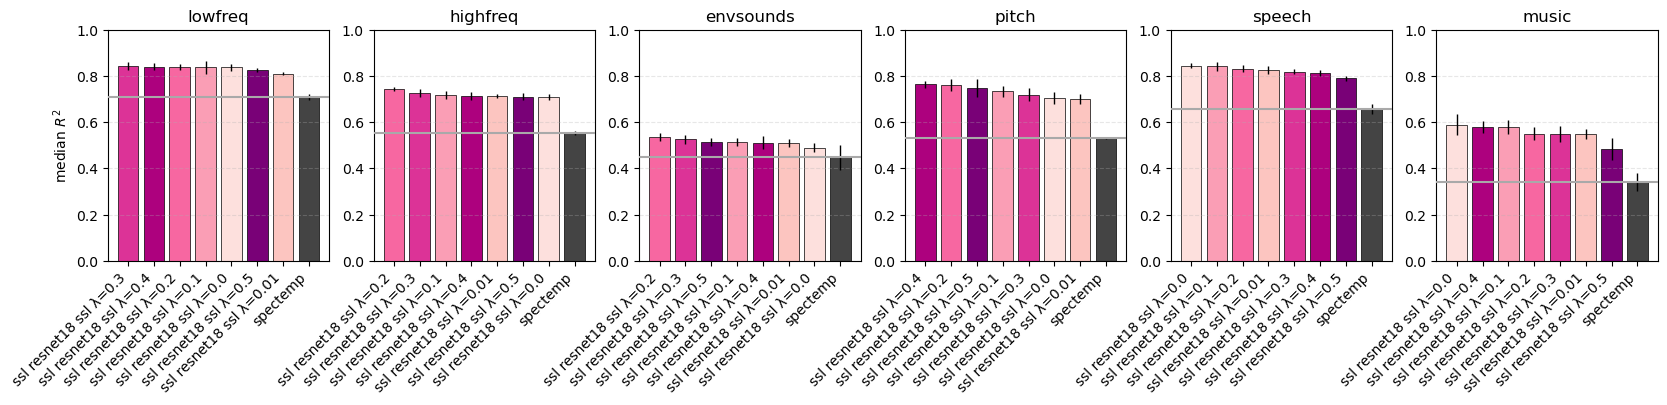

In [25]:

to_plot = results_df[~results_df.model_name_str.str.contains("dual|1.0")]

# Get all unique model names for building the palette
unique_models = to_plot['model_name_str'].unique()

# Build palette using standard utilities
base_colors = get_standard_base_colors()
hue_dict = build_model_palette(unique_models, base_colors)
hue_dict['byol-a'] = "k"

# Get spectrotemporal values for reference line
spectemp_vals = results_df[results_df.model_name_str.str.contains("spectemp")]

# Get unique components
components = to_plot['comp'].unique()

# Create figure with subplots for each component
n_components = len(components)
n_cols = 6
n_rows = (n_components + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 3))
if n_components == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for idx, component in enumerate(components):
    ax = axes[idx]
    
    # Filter data for this component
    comp_data = to_plot[to_plot['comp'] == component].copy()
    
    # Remove duplicates - keep first occurrence of each model_name_str
    comp_data = comp_data.drop_duplicates(subset=['model_name_str'], keep='first')
    
    # Sort by median_r2_test (highest to lowest)
    comp_data = comp_data.sort_values('median_r2_test', ascending=False)
    
    # Get the sorted order for this component
    comp_hue_order = comp_data['model_name_str'].values
    
    # Create x positions
    x_pos = np.arange(len(comp_hue_order))
    
    # Get colors for each model
    colors = [hue_dict.get(name, '#444444') for name in comp_hue_order]
    
    # Create barplot with styling matching plot_grouped_bars
    bar_width = 0.8
    bars = ax.bar(x_pos, comp_data['median_r2_test'].values, width=bar_width, 
                  color=colors, edgecolor='black', linewidth=0.5, zorder=0)
    
    # Add error bars (vertical lines) using median_r2_test_std_over_it
    # Match the styling from plot_grouped_bars: capsize=4, black color
    errors = comp_data['median_r2_test_std_over_it'].values
    ax.errorbar(x_pos, comp_data['median_r2_test'].values, yerr=errors, 
                fmt='none', color='black', capsize=0, capthick=1, elinewidth=1, zorder=4)
    
    # Add spectrotemporal reference line
    spectemp_row = spectemp_vals[spectemp_vals.comp == component]
    if len(spectemp_row) > 0:
        spectemp_med = spectemp_row['median_r2_test'].values[0]
        ax.axhline(spectemp_med, color='darkgrey', linestyle='-', linewidth=1.5, zorder=5, label='Spectrotemporal')
    
    # Set labels and title
    ax.set_title(f'{component}')
    if idx == 0 or idx == n_cols:
        ax.set_ylabel('median $R^2$')
    ax.set_xlabel('')
    ax.set_xticks(x_pos)
    
    # Create x-axis labels using model_label (strips "CochDNN9" prefix)
    # Add "ssl" or "scaled ssl" prefix for SSL models
    x_labels = []
    for name in comp_hue_order:
        label = model_label(name)
        # Check if it's an SSL model and add appropriate prefix
        if 'scaled ssl' in name:
            # For scaled SSL models, add "scaled ssl" prefix
            if label.startswith('λ='):
                lambda_val = label.replace('λ=', '')
                x_labels.append(f"scaled ssl λ={lambda_val}")
            else:
                x_labels.append(f"scaled ssl {label}")
        elif 'ssl' in name and 'scaled' not in name:
            # For regular SSL models, add "ssl" prefix
            if label.startswith('λ='):
                lambda_val = label.replace('λ=', '')
                x_labels.append(f"ssl λ={lambda_val}")
            else:
                x_labels.append(f"ssl {label}")
        else:
            # For supervised models, use label as is
            x_labels.append(label)
    ax.set_xticklabels(x_labels, rotation=45, ha='right')
    
    ax.set_ylim(0, 1)
    ax.grid(axis='y', alpha=0.3, linestyle='--', zorder=0)

# Hide extra subplots if any
for idx in range(n_components, len(axes)):
    axes[idx].set_visible(False)


In [26]:
to_plot.groupby('model_name_str').apply('median_r2_test').mean().sort_values(ascending=False)

model_name_str
resnet18 ssl λ=0.2     0.710130
resnet18 ssl λ=0.1     0.704154
resnet18 ssl λ=0.4     0.703749
resnet18 ssl λ=0.3     0.697230
resnet18 ssl λ=0.0     0.696266
resnet18 ssl λ=0.01    0.685038
resnet18 ssl λ=0.5     0.679095
spectemp               0.540452
Name: median_r2_test, dtype: float64

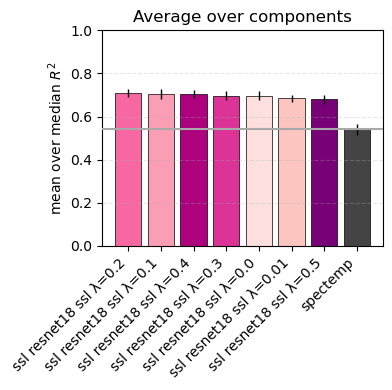

In [27]:
# Create a single panel version showing average over components
fig_avg, ax_avg = plt.subplots(1, 1, figsize=(4, 4))

# Calculate average across components for each model
avg_data = to_plot.groupby('model_name_str').agg({
    'median_r2_test': 'mean',
    'median_r2_test_std_over_it': 'mean'
}).reset_index()

# Remove duplicates
avg_data = avg_data.drop_duplicates(subset=['model_name_str'], keep='first')

# Sort by median_r2_test (highest to lowest)
avg_data = avg_data.sort_values('median_r2_test', ascending=False)

# Get the sorted order
avg_hue_order = avg_data['model_name_str'].values

# Create x positions
x_pos_avg = np.arange(len(avg_hue_order))

# Get colors for each model
colors_avg = [hue_dict.get(name, '#444444') for name in avg_hue_order]

# Create barplot with styling matching plot_grouped_bars
bar_width_avg = 0.8
bars_avg = ax_avg.bar(x_pos_avg, avg_data['median_r2_test'].values, width=bar_width_avg, 
                      color=colors_avg, edgecolor='black', linewidth=0.5, zorder=0)

# Add error bars
errors_avg = avg_data['median_r2_test_std_over_it'].values
ax_avg.errorbar(x_pos_avg, avg_data['median_r2_test'].values, yerr=errors_avg, 
                fmt='none', color='black', capsize=0, capthick=1, elinewidth=1, zorder=4)

# Add spectrotemporal reference line (average across components)
spectemp_avg = spectemp_vals.groupby('comp')['median_r2_test'].first().mean()
ax_avg.axhline(spectemp_avg, color='darkgrey', linestyle='-', linewidth=1.5, zorder=5, label='Spectrotemporal')

# Set labels and title
ax_avg.set_title('Average over components')
ax_avg.set_ylabel('mean over median $R^2$')
ax_avg.set_xlabel('')
ax_avg.set_xticks(x_pos_avg)

# Create x-axis labels using model_label (strips "CochDNN9" prefix)
# Add "ssl" or "scaled ssl" prefix for SSL models
x_labels_avg = []
for name in avg_hue_order:
    label = model_label(name)
    # Check if it's an SSL model and add appropriate prefix
    if 'scaled ssl' in name:
        # For scaled SSL models, add "scaled ssl" prefix
        if label.startswith('λ='):
            lambda_val = label.replace('λ=', '')
            x_labels_avg.append(f"scaled ssl λ={lambda_val}")
        else:
            x_labels_avg.append(f"scaled ssl {label}")
    elif 'ssl' in name and 'scaled' not in name:
        # For regular SSL models, add "ssl" prefix
        if label.startswith('λ='):
            lambda_val = label.replace('λ=', '')
            x_labels_avg.append(f"ssl λ={lambda_val}")
        else:
            x_labels_avg.append(f"ssl {label}")
    else:
        # For supervised models, use label as is
        x_labels_avg.append(label)
ax_avg.set_xticklabels(x_labels_avg, rotation=45, ha='right')

ax_avg.set_ylim(0, 1)
ax_avg.grid(axis='y', alpha=0.3, linestyle='--', zorder=0)

plt.tight_layout()
plt.show()